# IMU Data Analysis
Reads a rosbag and plots gyro, accelerometer, magnetometer, and orientation (Euler angles) time series.

In [36]:
from pathlib import Path
from rosbags.typesys import get_typestore, Stores, get_types_from_msg
from rosbags.rosbag2 import Reader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [37]:
# --- Configuration ---
NOTEBOOK_DIR = Path("__file__").resolve().parent if "__file__" in dir() else Path().resolve()                                            
BAG_PATH = NOTEBOOK_DIR.parents[1] / "src/data/emulator_data"
IMU_TOPIC = "/imu"
MSG_PATH = "/home/adrian/EECE5554/LAB3/src/imu_msg/msg/IMUmsg.msg"
MSG_TYPE = "imu_msg/msg/IMUmsg"

In [38]:
typestore = get_typestore(Stores.ROS2_HUMBLE)

def register_msg_file(typestore, msg_path: str, full_type_name: str):
    msg_text = Path(msg_path).read_text()
    add_types = get_types_from_msg(msg_text, full_type_name)
    typestore.register(add_types)

register_msg_file(typestore, MSG_PATH, MSG_TYPE)

In [39]:
def quaternion_to_euler(w, x, y, z):
    """Convert quaternion to Euler angles (roll, pitch, yaw) in degrees."""
    # Roll (x-axis)
    sinr_cosp = 2 * (w * x + y * z)
    cosr_cosp = 1 - 2 * (x * x + y * y)
    roll = np.arctan2(sinr_cosp, cosr_cosp)

    # Pitch (y-axis)
    sinp = 2 * (w * y - z * x)
    sinp = np.clip(sinp, -1.0, 1.0)
    pitch = np.arcsin(sinp)

    # Yaw (z-axis)
    siny_cosp = 2 * (w * z + x * y)
    cosy_cosp = 1 - 2 * (y * y + z * z)
    yaw = np.arctan2(siny_cosp, cosy_cosp)

    return np.degrees(roll), np.degrees(pitch), np.degrees(yaw)


def bag_to_df_imu(bag_path: str, typestore, topic: str = "/imu") -> pd.DataFrame:
    rows = []

    with Reader(bag_path) as reader:
        for connection, timestamp, rawdata in reader.messages():
            if connection.topic != topic:
                continue

            msg = typestore.deserialize_cdr(rawdata, connection.msgtype)

            qx = float(msg.imu.orientation.x)
            qy = float(msg.imu.orientation.y)
            qz = float(msg.imu.orientation.z)
            qw = float(msg.imu.orientation.w)
            roll, pitch, yaw = quaternion_to_euler(qw, qx, qy, qz)

            rows.append({
                "bag_time_ns": int(timestamp),

                # Gyroscope (rad/s)
                "gyro_x": float(msg.imu.angular_velocity.x),
                "gyro_y": float(msg.imu.angular_velocity.y),
                "gyro_z": float(msg.imu.angular_velocity.z),

                # Accelerometer (m/s^2)
                "accel_x": float(msg.imu.linear_acceleration.x),
                "accel_y": float(msg.imu.linear_acceleration.y),
                "accel_z": float(msg.imu.linear_acceleration.z),

                # Magnetometer (Tesla)
                "mag_x": float(msg.mag_field.magnetic_field.x),
                "mag_y": float(msg.mag_field.magnetic_field.y),
                "mag_z": float(msg.mag_field.magnetic_field.z),

                # Orientation quaternion
                "orient_qx": qx,
                "orient_qy": qy,
                "orient_qz": qz,
                "orient_qw": qw,

                # Euler angles (degrees)
                "roll_deg":  roll,
                "pitch_deg": pitch,
                "yaw_deg":   yaw,
            })

    df = pd.DataFrame(rows)
    df["time_s"] = (df["bag_time_ns"] - df["bag_time_ns"].iloc[0]) * 1e-9
    return df

In [40]:
df = bag_to_df_imu(BAG_PATH, typestore, topic=IMU_TOPIC)
print(f"Loaded {len(df)} IMU messages")
print(f"Duration: {df['time_s'].iloc[-1]:.2f} s")
df.head()

Loaded 624 IMU messages
Duration: 15.58 s


,bag_time_ns,gyro_x,gyro_y,gyro_z,accel_x,accel_y,accel_z,mag_x,mag_y,mag_z,orient_qx,orient_qy,orient_qz,orient_qw,roll_deg,pitch_deg,yaw_deg,time_s
0,1773109891184197284,-0.000189,0.000967,-0.000267,-5.984,-0.164,-7.864,0.000029,0.000007,0.000075,-0.315950,-0.049272,-0.939973,0.119163,1.248,-37.280,-165.971,0.000000
1,1773109891209027422,0.000007,-0.000193,0.000853,-5.974,-0.163,-7.828,0.000029,0.000008,0.000074,-0.315958,-0.049270,-0.939968,0.119176,1.247,-37.281,-165.969,0.024830
2,1773109891234588986,-0.000762,0.000907,-0.000230,-5.987,-0.175,-7.853,0.000029,0.000007,0.000075,-0.315949,-0.049275,-0.939969,0.119193,1.247,-37.280,-165.967,0.050392
3,1773109891258875148,-0.000239,-0.000423,-0.000154,-5.989,-0.151,-7.846,0.000029,0.000007,0.000074,-0.315948,-0.049280,-0.939969,0.119187,1.248,-37.280,-165.968,0.074678
4,1773109891284583538,-0.000203,0.001044,0.000875,-5.964,-0.158,-7.829,0.000029,0.000007,0.000074,-0.315949,-0.049272,-0.939967,0.119206,1.246,-37.280,-165.965,0.100386


## a. Gyroscope (X, Y, Z)

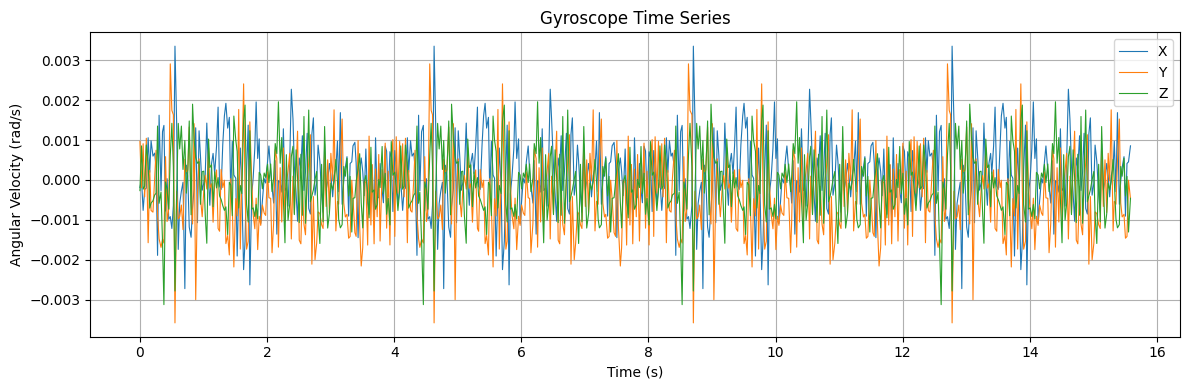

In [41]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["time_s"], df["gyro_x"], label="X", linewidth=0.8)
ax.plot(df["time_s"], df["gyro_y"], label="Y", linewidth=0.8)
ax.plot(df["time_s"], df["gyro_z"], label="Z", linewidth=0.8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Angular Velocity (rad/s)")
ax.set_title("Gyroscope Time Series")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## b. Accelerometer (X, Y, Z)

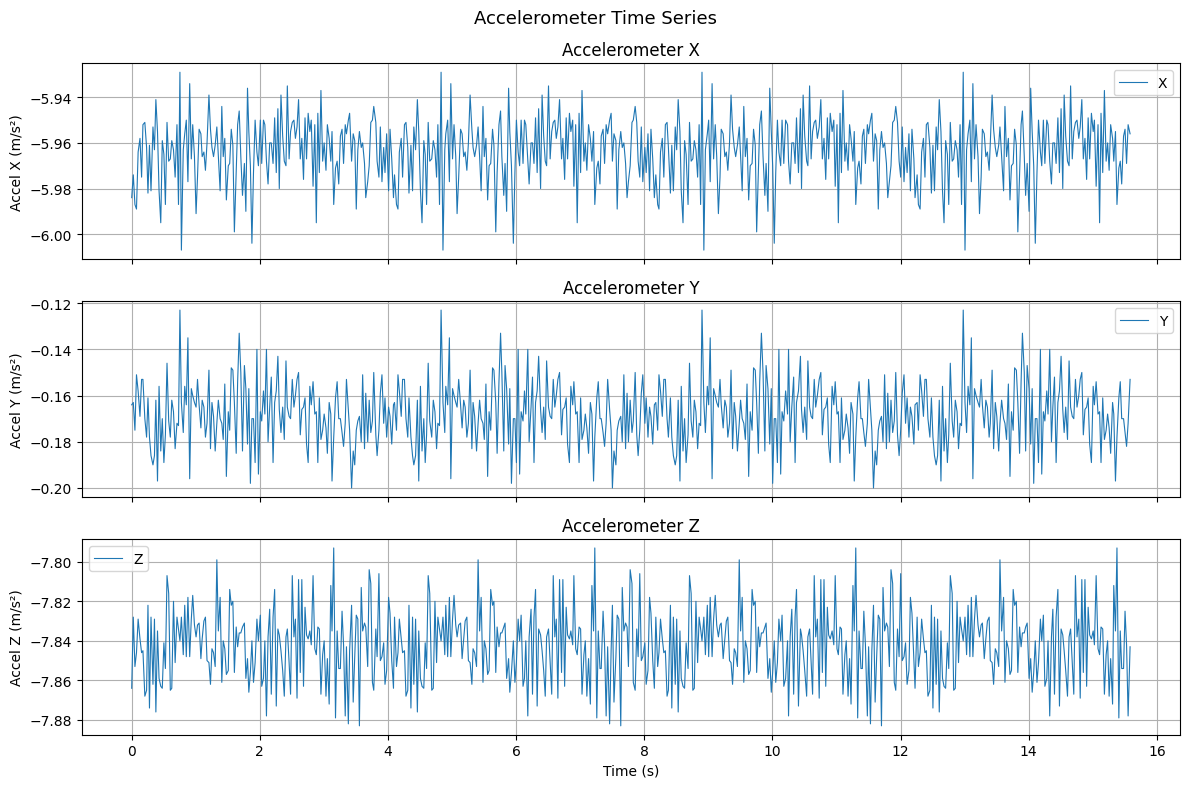

In [42]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, col, label in zip(axes, ["accel_x", "accel_y", "accel_z"], ["X", "Y", "Z"]):
    ax.plot(df["time_s"], df[col], linewidth=0.8, label=label)
    ax.set_ylabel(f"Accel {label} (m/s²)")
    ax.set_title(f"Accelerometer {label}")
    ax.legend()
    ax.grid(True)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Accelerometer Time Series", fontsize=13)
plt.tight_layout()
plt.show()

## c. Magnetometer (X, Y, Z)

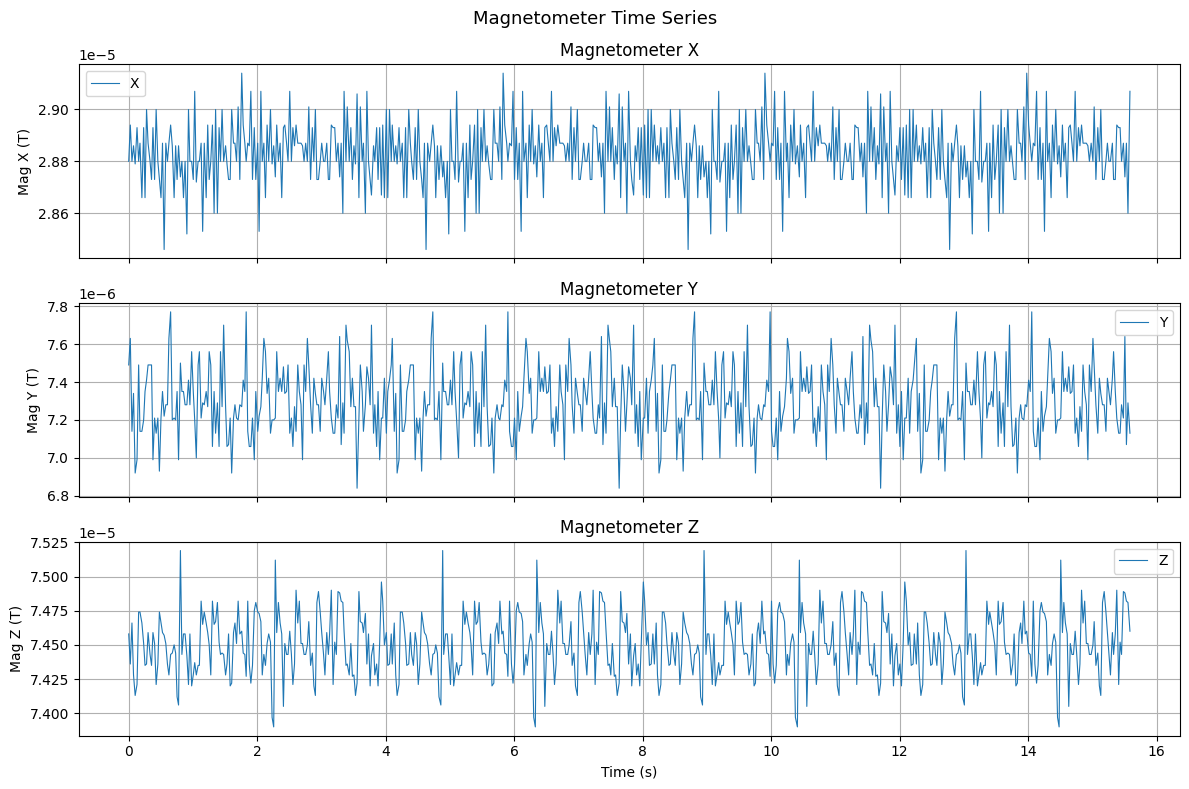

In [43]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, col, label in zip(axes, ["mag_x", "mag_y", "mag_z"], ["X", "Y", "Z"]):
    ax.plot(df["time_s"], df[col], linewidth=0.8, label=label)
    ax.set_ylabel(f"Mag {label} (T)")
    ax.set_title(f"Magnetometer {label}")
    ax.legend()
    ax.grid(True)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Magnetometer Time Series", fontsize=13)
plt.tight_layout()
plt.show()

## d. Orientation — Euler Angles (Roll, Pitch, Yaw)

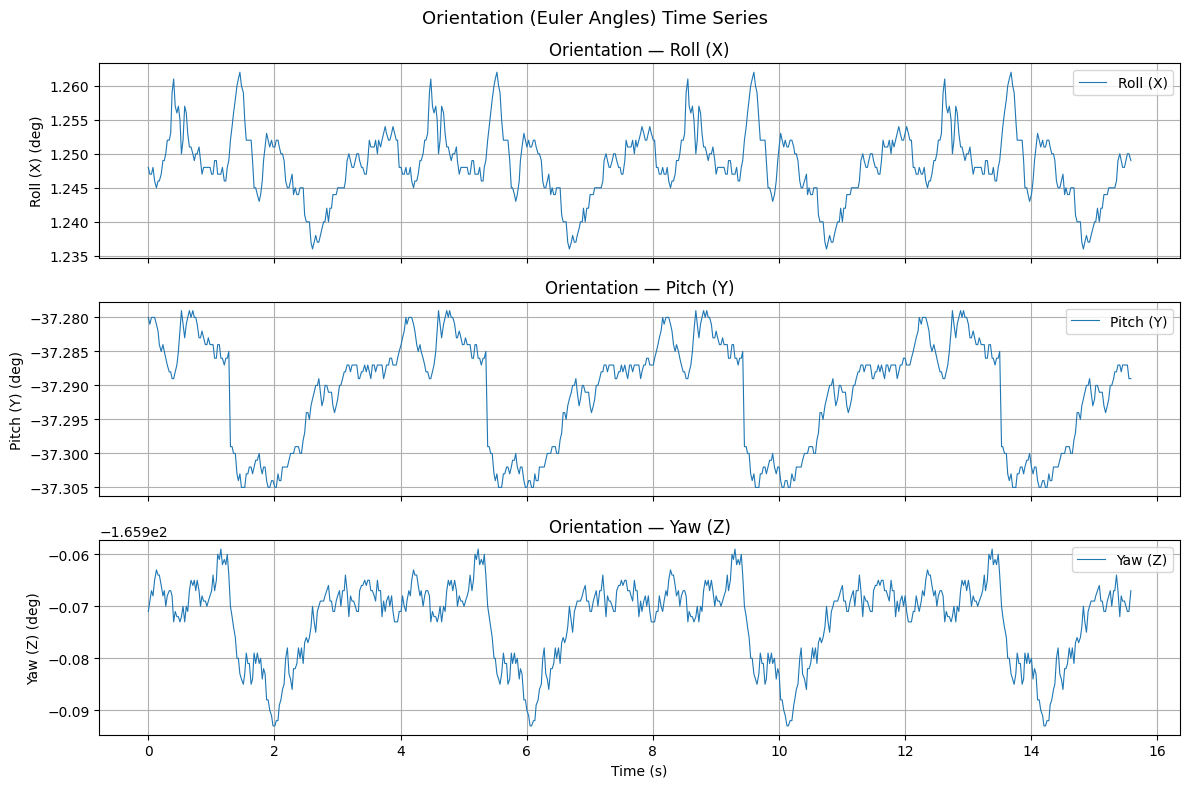

In [44]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, col, label in zip(axes,
                           ["roll_deg", "pitch_deg", "yaw_deg"],
                           ["Roll (X)", "Pitch (Y)", "Yaw (Z)"]):
    ax.plot(df["time_s"], df[col], linewidth=0.8, label=label)
    ax.set_ylabel(f"{label} (deg)")
    ax.set_title(f"Orientation — {label}")
    ax.legend()
    ax.grid(True)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Orientation (Euler Angles) Time Series", fontsize=13)
plt.tight_layout()
plt.show()

## e. Orientation Statistics and Histograms

In [45]:
from matplotlib.ticker import FormatStrFormatter

euler_cols = [("roll_deg", "Roll (X)"), ("pitch_deg", "Pitch (Y)"), ("yaw_deg", "Yaw (Z)")]

print(f"{'Axis':<12} {'Mean (deg)':>12} {'Median (deg)':>14}")
print("-" * 40)
for col, label in euler_cols:
    mean_val   = df[col].mean()
    median_val = df[col].median()
    print(f"{label:<12} {mean_val:>12.4f} {median_val:>14.4f}")

Axis           Mean (deg)   Median (deg)
----------------------------------------
Roll (X)           1.2485         1.2490
Pitch (Y)        -37.2912       -37.2880
Yaw (Z)         -165.9727      -165.9700


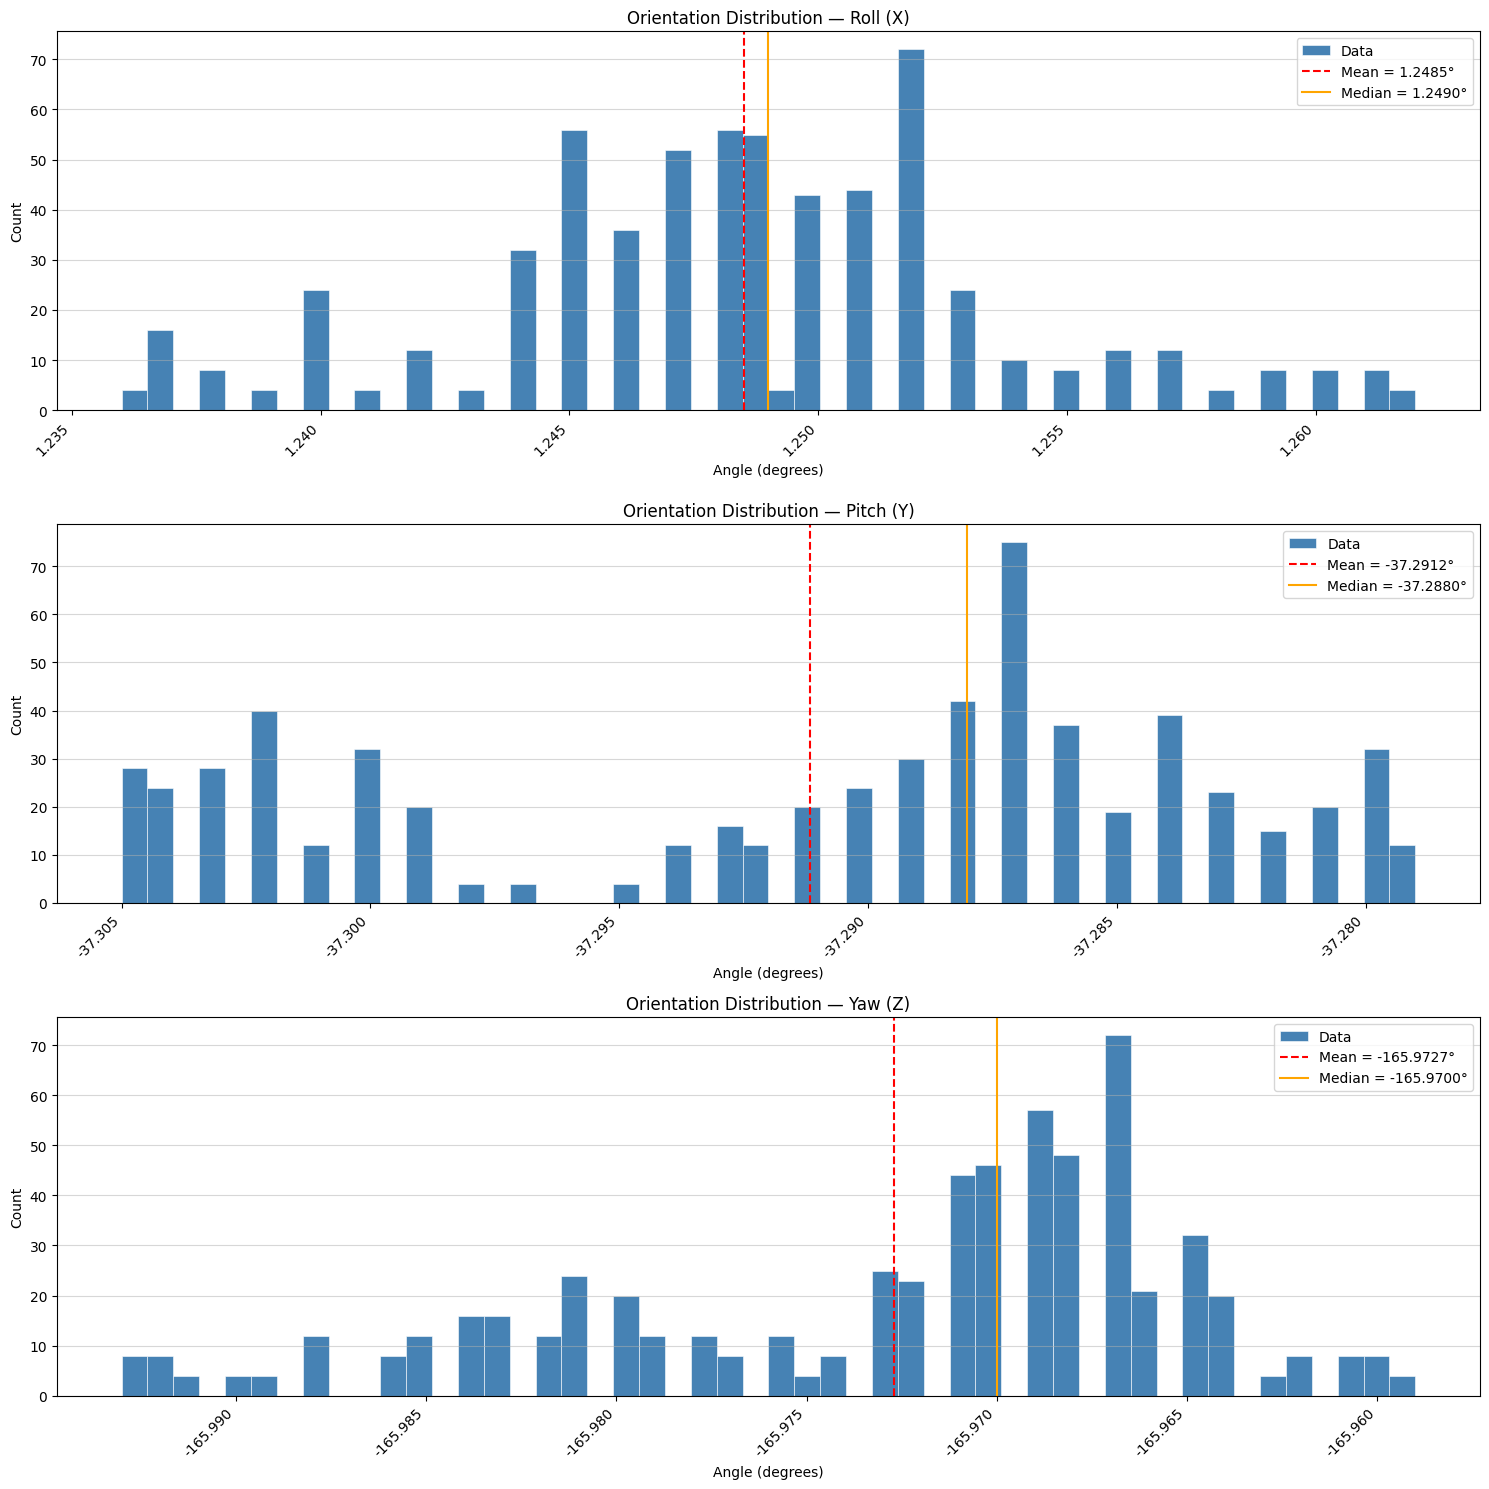

In [46]:
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

for ax, (col, label) in zip(axes, euler_cols):
    data       = df[col]
    mean_val   = data.mean()
    median_val = data.median()

    ax.hist(data, bins=50, color="steelblue", edgecolor="white", linewidth=0.4, label="Data")
    ax.axvline(mean_val,   color="red",    linestyle="--", linewidth=1.5, label=f"Mean = {mean_val:.4f}°")
    ax.axvline(median_val, color="orange", linestyle="-",  linewidth=1.5, label=f"Median = {median_val:.4f}°")

    ax.set_xlabel("Angle (degrees)")
    ax.set_ylabel("Count")
    ax.set_title(f"Orientation Distribution — {label}")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.5)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()